# Install Package

In [78]:
#!pip install yfinance pandas matplotlib openbb vectorbt "nbformat>=5.10"

# Trading system development

## Data preparation

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import vectorbt as vbt

from openbb import obb

obb.user.preferences.output_type = "dataframe"


def load_data(sector: str, symbol: str, start_date: str, end_date: str, interval: str = "1d") -> pd.DataFrame:
    """
    Load OHLCV price data via OpenBB (obb).

    Parameters
    ----------
    sector : str
        One of "stock", "crypto", "forex".
    symbol : str
        Ticker symbol. Stock e.g. "AAPL". Crypto e.g. "BTCUSD". Forex e.g. "EURUSD".
    start_date, end_date : str
        Format "YYYY-MM-DD".
    interval : str
        Price timeframe, e.g. "1m", "5m", "15m", "1h", "1d", "1W", "1M".
    """
    sector = sector.lower()

    if sector == "stock":
        df = obb.equity.price.historical(
            symbol=symbol, start_date=start_date, end_date=end_date, interval=interval
        )
    elif sector == "crypto":
        df = obb.crypto.price.historical(
            symbol=symbol, start_date=start_date, end_date=end_date, interval=interval
        )
    elif sector == "forex":
        df = obb.currency.price.historical(
            symbol=symbol, start_date=start_date, end_date=end_date, interval=interval
        )
    else:
        raise ValueError(f"Unsupported sector: {sector}. Choose 'stock', 'crypto', or 'forex'.")

    df.columns = [c.lower() for c in df.columns]
    return df


In [80]:
# Example usage
SECTOR = "crypto"       # "stock" | "crypto" | "forex"
SYMBOL = "BTCUSD"
START_DATE = "2020-01-01"
END_DATE = "2026-06-30"
INTERVAL = "1d"

data = load_data(SECTOR, SYMBOL, START_DATE, END_DATE, INTERVAL)
data.head()


,open,high,low,close,volume
date,,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,1.856566e+10
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,2.080208e+10
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,2.811148e+10
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,1.844427e+10
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,1.972507e+10


## Data Analysis & Signal Process

### Geometric Grid Trading (traditional, per paper arXiv:2506.11921 Sec 1.1)

Grid levels are placed at prices $P \cdot (1+k)^i$ for $i = -(n-m), \dots, 0, \dots, m$, where:

- $P$ = reference (starting) price — the initial **black** level
- $k$ = grid size (equal-ratio spacing between adjacent levels)
- $n$ = number of grids → $n+1$ grid levels
- $m$ = number of gray levels **above** $P$; $n-m$ gray levels **below**

**Initial setup**: with total capital $M$ USDT, spend $M \cdot \frac{m}{n}$ to buy crypto, keep $M \cdot \frac{n-m}{n}$ as USDT.

**Algorithm** (trade fires only when price *crosses a gray level*):

- Price **rises** across the $G_i$-th gray level counted from the **top** → **sell** $\frac{1}{G_i}$ of held crypto. Old black level turns gray, crossed level becomes the new black.
- Price **falls** across the $G_j$-th gray level counted from the **bottom** → **buy** with $\frac{1}{G_j}$ of held USDT. Same black/gray swap.

**Termination**: price exits above the top level (all crypto already sold → hold only USDT + arbitrage profit) or below the bottom level (all USDT already converted to crypto). The paper proves this terminating strategy has **zero expected value** before fees (Eqs. 1–6), which motivates DGT's grid-reset fix.

In [81]:
class GeometricGrid:
    """
    Traditional geometric grid trading strategy (arXiv:2506.11921, Sec 1.1).

    Grid levels: P * (1+k)^i  for i in [-(n-m), ..., 0, ..., m].
    One level is "black" (the current level); all others are "gray".
    A trade fires only when price crosses a gray level:
      - up-cross of the Gi-th gray level from the top    -> sell 1/Gi of crypto
      - down-cross of the Gj-th gray level from the bottom -> buy with 1/Gj of USDT
    Terminates when price exits the grid boundary.

    Parameters
    ----------
    P : float
        Reference price (grid center, initial black level).
    k : float
        Grid size — equal ratio between adjacent levels (e.g. 0.01 = 1%).
    n : int
        Number of grids (=> n+1 levels).
    m : int
        Number of gray levels above P (n - m below).
    M : float
        Total capital in quote currency (USDT).
    fee : float
        Proportional transaction fee (paper uses 0.0008, OKX L1 maker).
    """

    def __init__(self, P: float, k: float, n: int, m: int, M: float, fee: float = 0.0008):
        self.P, self.k, self.n, self.m, self.M, self.fee = P, k, n, m, M, fee

        # Level i=0 is the reference price P; positive i above, negative below.
        self.levels = np.array([P * (1 + k) ** i for i in range(-(n - m), m + 1)])
        self.black_idx = n - m                       # index of P inside self.levels

        # Initial split: buy M*m/n worth of crypto, keep M*(n-m)/n as USDT.
        spend = M * m / n
        self.crypto = spend * (1 - fee) / P          # crypto units held
        self.usdt = M * (n - m) / n                  # quote held
        self.terminated = False
        self.trades = []                             # trade log

    # -- internal helpers ---------------------------------------------------

    def _gray_above(self):
        """Indices of gray levels strictly above the black level."""
        return list(range(self.black_idx + 1, len(self.levels)))

    def _gray_below(self):
        """Indices of gray levels strictly below the black level."""
        return list(range(self.black_idx - 1, -1, -1))

    def _sell(self, level_idx: int, ts):
        # Gi = position of this gray level counted from the TOP limit.
        Gi = len(self.levels) - level_idx
        qty = self.crypto / Gi
        price = self.levels[level_idx]
        self.crypto -= qty
        self.usdt += qty * price * (1 - self.fee)
        self.black_idx = level_idx                   # black/gray swap
        self.trades.append(
            {"time": ts, "side": "sell", "price": price, "qty": qty,
             "usdt": self.usdt, "crypto": self.crypto}
        )

    def _buy(self, level_idx: int, ts):
        # Gj = position of this gray level counted from the BOTTOM limit.
        Gj = level_idx + 1
        spend = self.usdt / Gj
        price = self.levels[level_idx]
        self.usdt -= spend
        self.crypto += spend * (1 - self.fee) / price
        self.black_idx = level_idx                   # black/gray swap
        self.trades.append(
            {"time": ts, "side": "buy", "price": price, "qty": spend / price,
             "usdt": self.usdt, "crypto": self.crypto}
        )

    # -- main entry ---------------------------------------------------------

    def step(self, price: float, ts=None):
        """Feed one price observation. Executes any level crossings."""
        if self.terminated:
            return

        # Termination check: price exits the grid boundary.
        if price > self.levels[-1] * (1 + self.k) or price < self.levels[0] / (1 + self.k):
            self.terminated = True
            return

        # Up-crosses: sell at every gray level passed, nearest first.
        for idx in self._gray_above():
            if price >= self.levels[idx]:
                self._sell(idx, ts)
            else:
                break

        # Down-crosses: buy at every gray level passed, nearest first.
        for idx in self._gray_below():
            if price <= self.levels[idx]:
                self._buy(idx, ts)
            else:
                break

    def run(self, close: pd.Series) -> pd.DataFrame:
        """Run the grid over a close-price series. Returns trade log."""
        for ts, price in close.items():
            self.step(float(price), ts)
            if self.terminated:
                break
        return pd.DataFrame(self.trades)

    def equity(self, price: float) -> float:
        """Mark-to-market portfolio value at a given price."""
        return self.usdt + self.crypto * price


In [82]:
# Run the geometric grid on the loaded data and visualize grid levels + signals
close = data["close"]

P0 = float(close.iloc[0])   # reference price = first close
K = 0.02                    # grid size: 2% per level
N = 10                      # number of grids -> 11 levels
M_ABOVE = 5                 # gray levels above P (symmetric grid)
CAPITAL = 10_000            # USDT
FEE = 0.0008                # OKX Level-1 maker fee (per paper)

grid = GeometricGrid(P=P0, k=K, n=N, m=M_ABOVE, M=CAPITAL, fee=FEE)
trades = grid.run(close)

print(f"Grid levels ({len(grid.levels)}):")
print(np.round(grid.levels, 2))
print(f"\nTrades executed: {len(trades)}   Terminated: {grid.terminated}")
print(f"Final equity (mark-to-market at last price): {grid.equity(float(close.iloc[-1])):,.2f} USDT")
trades.head(10)


Grid levels (11):
[6521.42 6651.85 6784.89 6920.58 7058.99 7200.17 7344.18 7491.06 7640.88
 7793.7  7949.57]

Trades executed: 5   Terminated: True
Final equity (mark-to-market at last price): 24,435.85 USDT


,time,side,price,qty,usdt,crypto
0,2020-01-02,buy,7058.994428,0.141663,4000.000000,0.835422
1,2020-01-03,sell,7200.174316,0.139237,5001.728642,0.696185
2,2020-01-03,sell,7344.177803,0.139237,6023.491857,0.556948
3,2020-01-06,sell,7491.061359,0.139237,7065.690336,0.417711
4,2020-01-06,sell,7640.882586,0.139237,8128.732785,0.278474


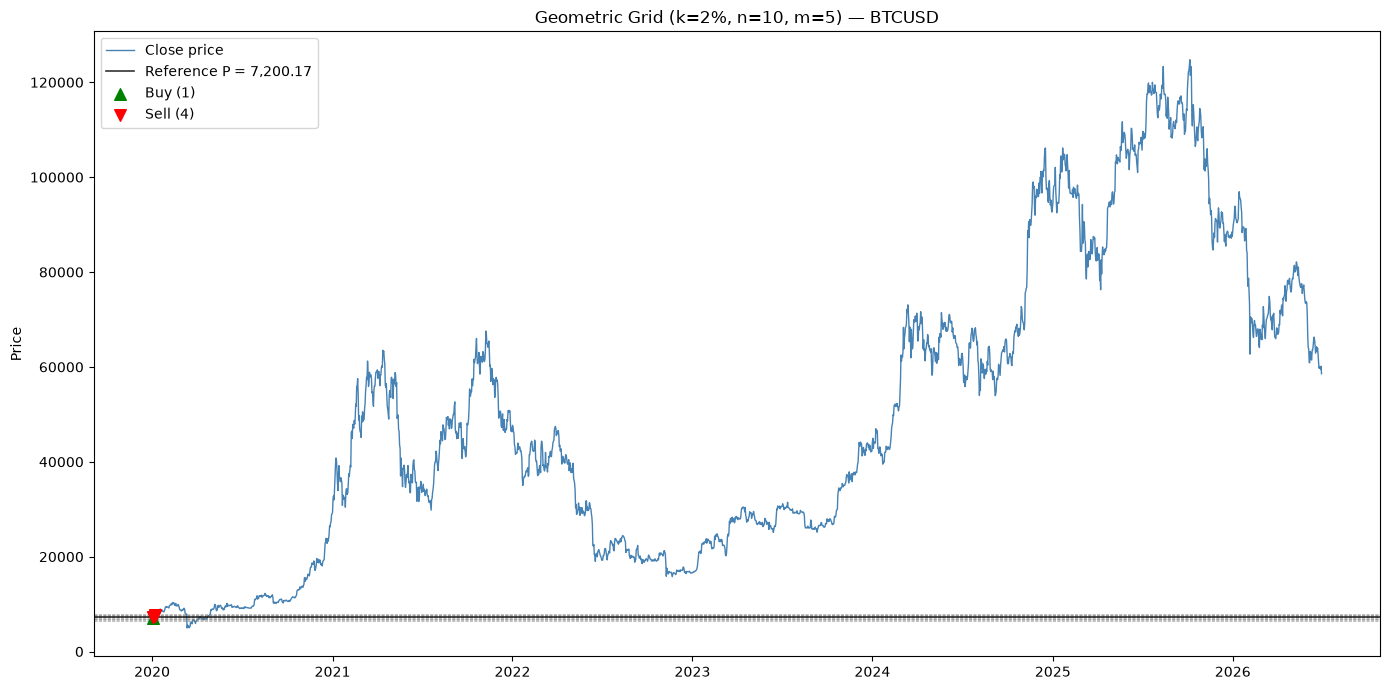

In [83]:
# Visualize: price path, geometric grid levels, buy/sell signals
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(close.index, close.values, lw=1, color="steelblue", label="Close price")

for lvl in grid.levels:
    ax.axhline(lvl, color="gray", ls="--", lw=0.6, alpha=0.6)
ax.axhline(grid.P, color="black", ls="-", lw=1.2, alpha=0.8, label=f"Reference P = {grid.P:,.2f}")

if not trades.empty:
    buys = trades[trades["side"] == "buy"]
    sells = trades[trades["side"] == "sell"]
    ax.scatter(buys["time"], buys["price"], marker="^", color="green", s=70, zorder=5, label=f"Buy ({len(buys)})")
    ax.scatter(sells["time"], sells["price"], marker="v", color="red", s=70, zorder=5, label=f"Sell ({len(sells)})")

ax.set_title(f"Geometric Grid (k={K:.0%}, n={N}, m={M_ABOVE}) — {SYMBOL}")
ax.set_ylabel("Price")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### Dynamic Grid-based Trading — DGT (arXiv:2506.11921, Sec 3 & Algorithm 1)

The traditional grid above **terminates** at the boundary — and the paper proves that rule makes its expected value exactly **zero** before fees (Eqs. 1–6), hence *negative* after fees:

$$E(G) = \tfrac{1}{2}(P_u - L_l) = -\tfrac{M}{n}\left(\tfrac{n^2}{8} - \tfrac{n}{4}\right), \qquad E_0 = \tfrac{n^2}{4} \;\Rightarrow\; \tfrac{n^2/4 - n/2}{2} = \tfrac{n^2}{8} - \tfrac{n}{4} \;\Rightarrow\; E(\text{grid}) = 0$$

The in-grid arbitrage profit exactly cancels the boundary-termination loss. **DGT's fix — the grid reset**: never terminate. Whenever price breaches the upper or lower boundary, **reset** the grid with the current price as the new center and keep trading.

The implementation below keeps *only* this reset idea: on each boundary breach the portfolio is marked to market and fully reinvested as the principal of a fresh symmetric grid centered at the breakout price (re-split $\tfrac{m}{n}$ crypto / $\tfrac{n-m}{n}$ USDT).

Parameters follow the paper: **grid size** $k$ (step ratio) and **grid numbers half** (levels above *and* below the center, i.e. $n = 2 \cdot \text{half}$, $m = \text{half}$). Paper backtests (BTC/ETH 1-min klines, Jan 2021–Jul 2024, fee 0.0008) show IRR up to 60–70% and MDD ~50% during an ~80% market crash.

In [84]:
class DGTStrategy:
    """
    Dynamic Grid-based Trading (arXiv:2506.11921, Sec 3 & Algorithm 1) —
    simplified to the paper's core idea only: when price breaches a grid
    boundary, do NOT terminate. Reset the grid with the current price as
    the new center and keep trading.

    On each reset the whole portfolio is marked to market and reinvested
    as the new grid's principal (re-split m/n crypto, (n-m)/n USDT).

    Parameters
    ----------
    k : float
        Grid size (equal ratio between adjacent levels).
    half : int
        Grid numbers half — gray levels above AND below the center
        (paper's parameter; the grid is symmetric: n = 2*half, m = half).
    M : float
        Initial capital in quote currency (USDT).
    fee : float
        Proportional transaction fee (paper uses 0.0008).
    """

    def __init__(self, k: float, half: int, M: float, fee: float = 0.0008):
        self.k, self.half, self.fee = k, half, fee
        self.episode = 0
        self.trades = []             # trade log across all episodes
        self.resets = []             # reset-event log
        self.equity_curve = []       # (ts, mark-to-market equity)
        self.grid = None
        self._principal = M

    def _new_grid(self, price: float, principal: float):
        """Start a fresh symmetric grid centered at the current price."""
        self.episode += 1
        self._episode_trades = 0
        self._principal = principal
        self.grid = GeometricGrid(
            P=price, k=self.k, n=2 * self.half, m=self.half,
            M=principal, fee=self.fee,
        )

    def _collect_trades(self):
        """Copy new grid trades into the global log, tagged by episode."""
        for t in self.grid.trades[self._episode_trades:]:
            self.trades.append({**t, "episode": self.episode})
        self._episode_trades = len(self.grid.trades)

    def _reset(self, price: float, ts, direction: str):
        """DGT's core fix: re-center the grid at the breakout price.

        First execute the level crossings a discrete-bar gap may have
        skipped, so the old grid finishes fully in USDT (up breakout) or
        fully in crypto (down breakout) as in the paper. Then mark the
        portfolio to market and reinvest it in a new grid.
        """
        if direction == "up":
            for idx in self.grid._gray_above():
                self.grid._sell(idx, ts)
        else:
            for idx in self.grid._gray_below():
                self.grid._buy(idx, ts)
        self._collect_trades()

        principal = self.grid.equity(price)
        self.resets.append(
            {"time": ts, "direction": direction, "old_center": self.grid.P,
             "new_center": price, "principal": principal}
        )
        self._new_grid(price, principal)

    def equity(self, price: float) -> float:
        """Mark-to-market portfolio value at a given price."""
        return self.grid.equity(price)

    def step(self, price: float, ts=None):
        if self.grid is None:
            self._new_grid(price, self._principal)

        # Boundary breach -> reset instead of terminating.
        if price > self.grid.levels[-1] * (1 + self.k):
            self._reset(price, ts, "up")
        elif price < self.grid.levels[0] / (1 + self.k):
            self._reset(price, ts, "down")
        else:
            self.grid.step(price, ts)
            self._collect_trades()

        self.equity_curve.append((ts, self.equity(price)))

    def run(self, close: pd.Series):
        """Run DGT over a close-price series.

        Returns (trades, resets) as DataFrames.
        """
        for ts, price in close.items():
            self.step(float(price), ts)
        return pd.DataFrame(self.trades), pd.DataFrame(self.resets)


In [85]:
# Run DGT on the loaded data: signals, reset log, and performance vs buy-and-hold
HALF = 5                    # grid numbers half (paper's parameter name)

dgt = DGTStrategy(k=K, half=HALF, M=CAPITAL, fee=FEE)
dgt_trades, resets = dgt.run(close)
dgt_equity = pd.Series(dict(dgt.equity_curve), name="dgt_equity")

# Buy-and-hold benchmark on the same capital (fee on the initial buy)
bh_equity = CAPITAL * (1 - FEE) * close / float(close.iloc[0])

# --- Performance metrics (paper Sec 4: IRR + MDD) ---
def irr_annualized(equity: pd.Series) -> float:
    days = (equity.index[-1] - equity.index[0]).days
    return (equity.iloc[-1] / equity.iloc[0]) ** (365.0 / days) - 1

def max_drawdown(equity: pd.Series) -> float:
    return float((equity / equity.cummax() - 1).min())

n_up = (resets["direction"] == "up").sum() if not resets.empty else 0
n_down = (resets["direction"] == "down").sum() if not resets.empty else 0
print(f"Trades: {len(dgt_trades)}   Grid resets: {len(resets)} (up: {n_up}, down: {n_down})")
print(f"Final equity: {dgt_equity.iloc[-1]:,.2f} USDT (start {CAPITAL:,.0f})")
print()
print(f"{'':>12} {'IRR':>10} {'MDD':>10}")
print(f"{'DGT':>12} {irr_annualized(dgt_equity):>10.2%} {max_drawdown(dgt_equity):>10.2%}")
print(f"{'Buy & hold':>12} {irr_annualized(bh_equity):>10.2%} {max_drawdown(bh_equity):>10.2%}")

resets.head(10)


Trades: 1457   Grid resets: 104 (up: 62, down: 42)
Final equity: 562.50 USDT (start 10,000)

                    IRR        MDD
         DGT    -35.78%    -94.90%
  Buy & hold     38.06%    -76.63%


,time,direction,old_center,new_center,principal
0,2020-01-07,up,7200.174316,8163.692383,10319.025447
1,2020-01-28,up,8163.692383,9358.589844,10686.602313
2,2020-03-08,down,9358.589844,8108.116211,9686.955086
3,2020-03-12,down,8108.116211,4970.788086,6116.803114
4,2020-03-19,up,4970.788086,6191.192871,6359.192349
5,2020-04-06,up,6191.192871,7271.781250,6665.828201
6,2020-04-29,up,7271.781250,8801.038086,6934.912669
7,2020-05-07,up,8801.038086,9951.518555,7142.704405
8,2020-05-10,down,9951.518555,8756.430664,6473.398834
9,2020-06-01,up,8756.430664,10167.268555,6742.383520


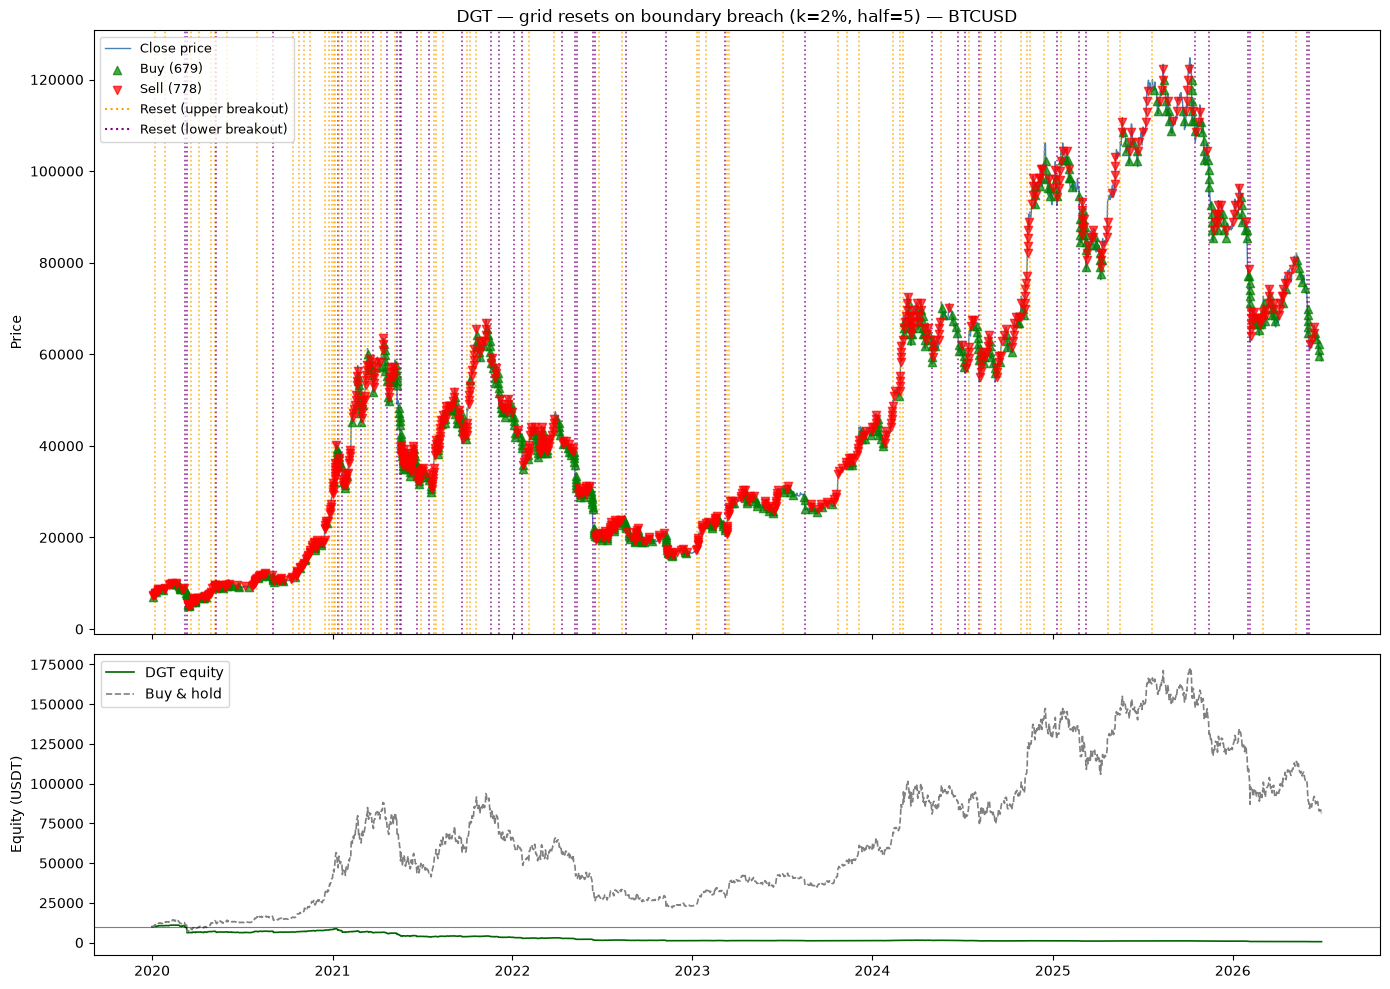

In [86]:
# Visualize DGT: grid resets on the price path (top) + equity vs buy-and-hold (bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# --- Top: price, all trades, and reset events ---
ax1.plot(close.index, close.values, lw=1, color="steelblue", label="Close price")

if not dgt_trades.empty:
    b = dgt_trades[dgt_trades["side"] == "buy"]
    s = dgt_trades[dgt_trades["side"] == "sell"]
    ax1.scatter(b["time"], b["price"], marker="^", color="green", s=35, alpha=0.7,
                zorder=4, label=f"Buy ({len(b)})")
    ax1.scatter(s["time"], s["price"], marker="v", color="red", s=35, alpha=0.7,
                zorder=4, label=f"Sell ({len(s)})")

if not resets.empty:
    for _, r in resets.iterrows():
        c = "orange" if r["direction"] == "up" else "purple"
        ax1.axvline(r["time"], color=c, ls=":", lw=1.2, alpha=0.8)
    ax1.plot([], [], color="orange", ls=":", label="Reset (upper breakout)")
    ax1.plot([], [], color="purple", ls=":", label="Reset (lower breakout)")

ax1.set_title(f"DGT — grid resets on boundary breach (k={K:.0%}, half={HALF}) — {SYMBOL}")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left", fontsize=9)

# --- Bottom: equity curves ---
ax2.plot(dgt_equity.index, dgt_equity.values, lw=1.2, color="darkgreen", label="DGT equity")
ax2.plot(bh_equity.index, bh_equity.values, lw=1.2, color="gray", ls="--", label="Buy & hold")
ax2.axhline(CAPITAL, color="black", lw=0.8, alpha=0.5)
ax2.set_ylabel("Equity (USDT)")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


## Create Trading Strategy

### Grid Signal Strategy — Geometric range + DGT reset validation

Combines the two components from the analysis section into one signal-generating strategy:

| Component | Role |
|---|---|
| **GeometricGrid** | Creates the trading range: grid levels $P \cdot (1+k)^i$ define **entry** prices (levels below the current black level) and **take-profit** prices (one grid step above each entry) |
| **DGT reset** | Validates the grid: when price breaks a boundary the range is **invalid** → emit a **stop-loss** signal that closes every open position, then build a new geometric grid centered at the current price |

Signal flow per bar (long-only):

1. Price **down-crosses** a grid level → `entry` signal at that level, TP set one grid step above.
2. Price **up-crosses** a grid level → `tp` signal for every open lot whose target is reached.
3. Price **exits the grid boundary** → `sl_reset` signal closes all open lots at market, then a fresh geometric grid is built at the breakout price (DGT reset).

Output: an event log (`signals` DataFrame with `entry` / `tp` / `sl_reset` rows) plus `to_signals()`, which nets the events per bar into `entries` / `exits` booleans and a `size` Series (lots per bar) — the exact input format of `vbt.Portfolio.from_signals(..., accumulate=True)` used in the Backtesting section. Position sizing beyond lots is left to Money Management.

In [ ]:
class GridSignalStrategy:
    """
    Signal generator combining GeometricGrid (levels) and DGT (reset).

    Roles:
    - Geometric grid defines the trading range: entry levels are the grid
      levels BELOW the current black level, and each entry's take-profit
      is the next grid level ABOVE its entry level.
    - DGT reset is the validity check / stop-loss: when price breaks a
      grid boundary the grid is invalid -> emit one SL signal that closes
      every open position, then build a new geometric grid centered at
      the current price.

    Emitted signals (long-only):
    - "entry"    price down-crossed a grid level -> open a lot at that
                 level, TP = one grid step above it
    - "tp"       price up-crossed a level -> close all open lots whose TP
                 is at or below the crossed level (FIFO)
    - "sl_reset" price left the grid -> close ALL open lots at market,
                 grid rebuilt at the current price

    `to_signals()` exports the event log in the exact form
    `vbt.Portfolio.from_signals(..., accumulate=True)` expects:
    boolean entries/exits plus a per-bar size Series (in lots) that
    preserves multi-lot bars.

    Parameters
    ----------
    k : float
        Grid size (equal ratio between adjacent levels).
    half : int
        Grid numbers half — levels above AND below the center.
    """

    def __init__(self, k: float, half: int):
        self.k, self.half = k, half
        self.episode = 0
        self.signals = []            # signal event log
        self.resets = []             # grid rebuild log
        self.open_lots = []          # open entries: {entry price, tp price, ...}
        self.levels = None
        self.black_idx = None

    def _new_grid(self, price: float, ts=None):
        """Geometric grid centered at the current price (symmetric)."""
        self.episode += 1
        self.levels = np.array(
            [price * (1 + self.k) ** i for i in range(-self.half, self.half + 1)]
        )
        self.black_idx = self.half

    def _emit(self, ts, signal: str, price: float, **extra):
        self.signals.append(
            {"time": ts, "signal": signal, "price": price,
             "episode": self.episode, **extra}
        )

    def _entry(self, level_idx: int, ts):
        """Down-cross: open a lot at this level, TP one grid step above."""
        entry_price = self.levels[level_idx]
        tp_price = self.levels[level_idx + 1]
        self.open_lots.append(
            {"time": ts, "entry": entry_price, "tp": tp_price, "episode": self.episode}
        )
        self._emit(ts, "entry", entry_price, tp=tp_price, level_idx=level_idx)
        self.black_idx = level_idx

    def _take_profit(self, level_idx: int, ts):
        """Up-cross: close every open lot whose TP is reached."""
        crossed = self.levels[level_idx]
        remaining = []
        for lot in self.open_lots:
            if lot["tp"] <= crossed + 1e-9:
                self._emit(ts, "tp", lot["tp"], entry=lot["entry"],
                           level_idx=level_idx)
            else:
                remaining.append(lot)
        self.open_lots = remaining
        self.black_idx = level_idx

    def _sl_reset(self, price: float, ts, direction: str):
        """DGT reset: grid invalid -> close all positions, rebuild grid."""
        if self.open_lots:
            self._emit(ts, "sl_reset", price, closed_lots=len(self.open_lots),
                       direction=direction)
            self.open_lots = []
        self.resets.append(
            {"time": ts, "direction": direction,
             "old_center": self.levels[self.half], "new_center": price}
        )
        self._new_grid(price, ts)

    def step(self, price: float, ts=None):
        if self.levels is None:
            self._new_grid(price, ts)

        # DGT validity check: boundary breach -> SL + new grid.
        if price > self.levels[-1] * (1 + self.k):
            self._sl_reset(price, ts, "up")
            return
        if price < self.levels[0] / (1 + self.k):
            self._sl_reset(price, ts, "down")
            return

        # Up-crosses: take profit at every level passed, nearest first.
        for idx in range(self.black_idx + 1, len(self.levels)):
            if price >= self.levels[idx]:
                self._take_profit(idx, ts)
            else:
                break

        # Down-crosses: entry at every level passed, nearest first.
        for idx in range(self.black_idx - 1, -1, -1):
            if price <= self.levels[idx]:
                self._entry(idx, ts)
            else:
                break

    def run(self, close: pd.Series):
        """Run over a close-price series.

        Returns (signals, resets) as DataFrames.
        """
        for ts, price in close.items():
            self.step(float(price), ts)
        return pd.DataFrame(self.signals), pd.DataFrame(self.resets)

    def to_signals(self, index: pd.Index):
        """Export signals for `vbt.Portfolio.from_signals(accumulate=True)`.

        Nets all events per bar into lot flow (+1 per entry, -1 per tp,
        -closed_lots per sl_reset), then splits into:

        Returns
        -------
        entries : pd.Series of bool
            True where the net lot flow of the bar is positive.
        exits : pd.Series of bool
            True where the net lot flow of the bar is negative
            (TP and SL-reset closes combined).
        size : pd.Series of float
            Absolute net lots traded on each signal bar (0 elsewhere).
            Multiply by a lot's asset quantity for `size=` in vectorbt.
        """
        flow = pd.Series(0.0, index=index)
        for s in self.signals:
            if s["signal"] == "entry":
                flow.loc[s["time"]] += 1.0
            elif s["signal"] == "tp":
                flow.loc[s["time"]] -= 1.0
            else:                          # "sl_reset"
                flow.loc[s["time"]] -= float(s["closed_lots"])
        entries = flow > 0
        exits = flow < 0
        size = flow.abs()
        return entries, exits, size


In [ ]:
# Generate signals on the loaded data
sig = GridSignalStrategy(k=K, half=HALF)
sig_signals, sig_resets = sig.run(close)
entries, exits, lot_size = sig.to_signals(close.index)

n_ent = (sig_signals["signal"] == "entry").sum() if not sig_signals.empty else 0
n_tp = (sig_signals["signal"] == "tp").sum() if not sig_signals.empty else 0
n_sl = (sig_signals["signal"] == "sl_reset").sum() if not sig_signals.empty else 0

print(f"Episodes (grids built): {sig.episode}   Rebuilds: {len(sig_resets)}")
print(f"Signals — entry: {n_ent}   TP exit: {n_tp}   SL close (reset): {n_sl}")
print(f"Open lots still held at end: {len(sig.open_lots)}")
print(f"\nvbt.Portfolio.from_signals inputs: "
      f"entry bars={int(entries.sum())}, exit bars={int(exits.sum())}, "
      f"lots traded={lot_size.sum():.0f}")
sig_signals.head(12)


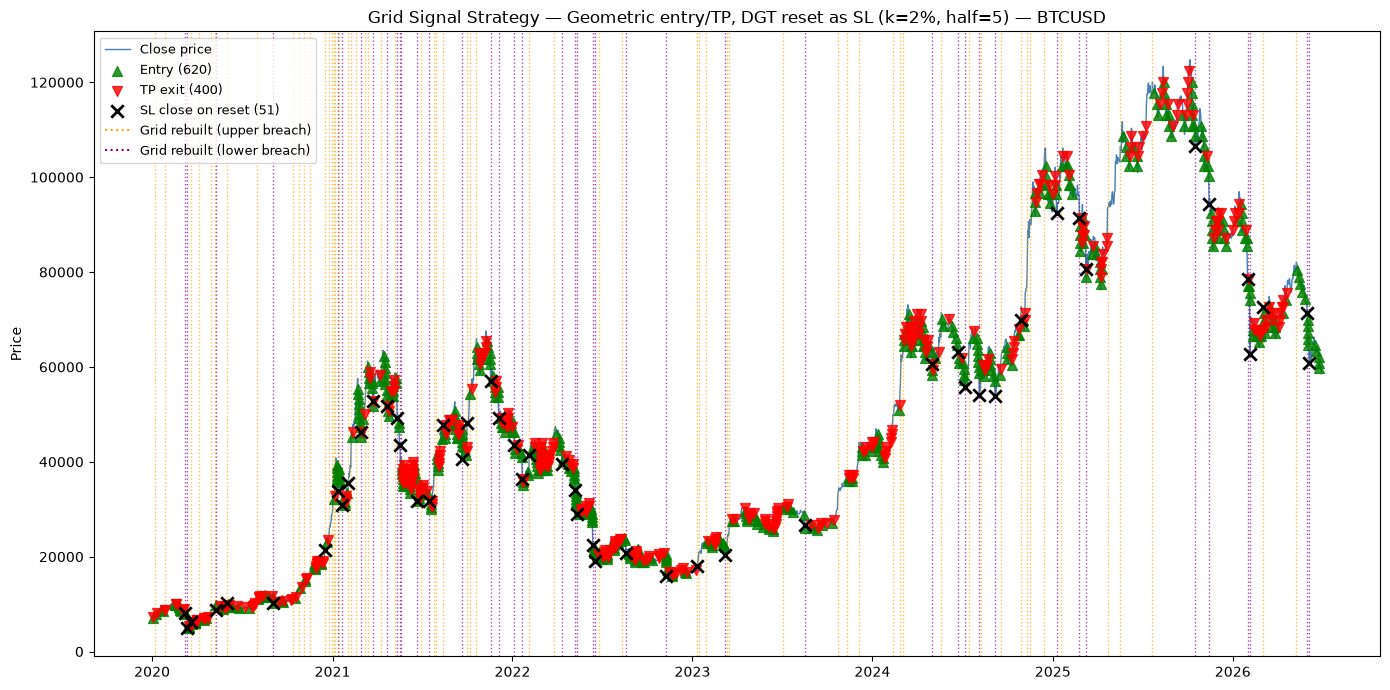

In [89]:
# Visualize: Geometric entries / TP exits, DGT reset = SL close + new grid
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(close.index, close.values, lw=1, color="steelblue", label="Close price")

if not sig_signals.empty:
    ent = sig_signals[sig_signals["signal"] == "entry"]
    tp = sig_signals[sig_signals["signal"] == "tp"]
    sl = sig_signals[sig_signals["signal"] == "sl_reset"]
    ax.scatter(ent["time"], ent["price"], marker="^", color="green", s=50, alpha=0.8,
               zorder=5, label=f"Entry ({len(ent)})")
    ax.scatter(tp["time"], tp["price"], marker="v", color="red", s=50, alpha=0.8,
               zorder=5, label=f"TP exit ({len(tp)})")
    ax.scatter(sl["time"], sl["price"], marker="x", color="black", s=80, lw=2,
               zorder=6, label=f"SL close on reset ({len(sl)})")

if not sig_resets.empty:
    for _, r in sig_resets.iterrows():
        c = "orange" if r["direction"] == "up" else "purple"
        ax.axvline(r["time"], color=c, ls=":", lw=1.0, alpha=0.7)
    ax.plot([], [], color="orange", ls=":", label="Grid rebuilt (upper breach)")
    ax.plot([], [], color="purple", ls=":", label="Grid rebuilt (lower breach)")

ax.set_title(f"Grid Signal Strategy — Geometric entry/TP, DGT reset as SL "
             f"(k={K:.0%}, half={HALF}) — {SYMBOL}")
ax.set_ylabel("Price")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


## Backtesting

### Backtest — GridSignalStrategy through `vbt.Portfolio.from_signals`

Feeds the output of `to_signals()` from the **Create Trading Strategy** section directly into vectorbt:

- **Signals**: boolean `entries` / `exits` plus a per-bar `lot_size` Series. `accumulate=True` makes entry signals stack lots and exit signals remove only that bar's lots (partial close) — this preserves the grid's per-lot behavior that plain boolean signals would collapse.
- **Sizing**: one lot = `CAPITAL / (2·half)` USDT of crypto at the first close; `size = lot_size × LOT_UNITS`, `size_type="amount"`.
- **Safety**: `direction="longonly"` — vectorbt clips any oversized exit so the position never goes short.
- **Costs**: same proportional fee (`FEE`) on every order; buy-and-hold benchmark (`vbt.Portfolio.from_holding`) pays the same fee on its initial buy.

Compared on total return, max drawdown, trade count, win rate, Sharpe and Calmar.

In [ ]:
# --- Backtest: GridSignalStrategy through vbt.Portfolio.from_signals ---
# entries/exits/lot_size come straight from sig.to_signals() in the
# Create Trading Strategy section. accumulate=True lets entry signals stack
# lots and exit signals remove only the bar's lot count (partial closes),
# matching the grid's per-lot behavior. direction='longonly' guarantees the
# position can never go short even if an exit size overshoots.
N_SLOTS = 2 * HALF                                  # max lots the grid can stack
LOT_UNITS = (CAPITAL / N_SLOTS) / float(close.iloc[0])  # crypto units per lot

freq = pd.infer_freq(close.index) or "1D"

pf_sig = vbt.Portfolio.from_signals(
    close,
    entries,
    exits,
    size=lot_size * LOT_UNITS,      # per-bar order size in asset units
    size_type="amount",
    accumulate=True,
    direction="longonly",
    init_cash=CAPITAL,
    fees=FEE,
    freq=freq,
)

# Buy-and-hold benchmark under identical costs
pf_bh = vbt.Portfolio.from_holding(close, init_cash=CAPITAL, fees=FEE, freq=freq)

stats = pd.DataFrame({
    "GridSignal": pf_sig.stats(),
    "Buy & Hold": pf_bh.stats(),
})
stats.loc[["Start", "End", "Total Return [%]", "Max Drawdown [%]",
           "Total Trades", "Win Rate [%]", "Sharpe Ratio", "Calmar Ratio"]]


In [ ]:
# --- Compare equity curves + drawdowns: signal strategy vs buy-and-hold ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

val_sig = pf_sig.value()
val_bh = pf_bh.value()

ax1.plot(val_sig.index, val_sig.values, lw=1.3, color="darkgreen",
         label="GridSignalStrategy (vectorbt)")
ax1.plot(val_bh.index, val_bh.values, lw=1.3, color="gray", ls="--", label="Buy & hold")
ax1.axhline(CAPITAL, color="black", lw=0.8, alpha=0.5)
ax1.set_ylabel("Portfolio value (USDT)")
ax1.set_title(f"Backtest — Geometric entry/TP + DGT reset SL (k={K:.0%}, half={HALF}) — {SYMBOL}")
ax1.legend(loc="upper left")

dd_sig = val_sig / val_sig.cummax() - 1
dd_bh = val_bh / val_bh.cummax() - 1
ax2.fill_between(dd_sig.index, dd_sig.values, 0, color="darkgreen", alpha=0.35,
                 label="Strategy drawdown")
ax2.fill_between(dd_bh.index, dd_bh.values, 0, color="gray", alpha=0.25,
                 label="Buy & hold drawdown")
ax2.set_ylabel("Drawdown")
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()


## System Evaluation